In [1]:
import sys
import sys, os, glob
# the chapter programs live in BookPrograms/chapterNN; put them all on the path
for _d in sorted(glob.glob(os.path.join("..", "BookManybody",
                                        "BookPrograms", "chapter*"))):
    if _d not in sys.path:
        sys.path.insert(0, _d)

import itertools
import math
import numpy as np
import matplotlib.pyplot as plt

import rbm as bm
from vmcoptimise import blocking

      quantity     exact     direct      Gibbs
        mean x    0.0000     0.0001     0.0014
         var x    1.0000     0.9998     0.9977
   correlation    0.8000     0.7994     0.8005


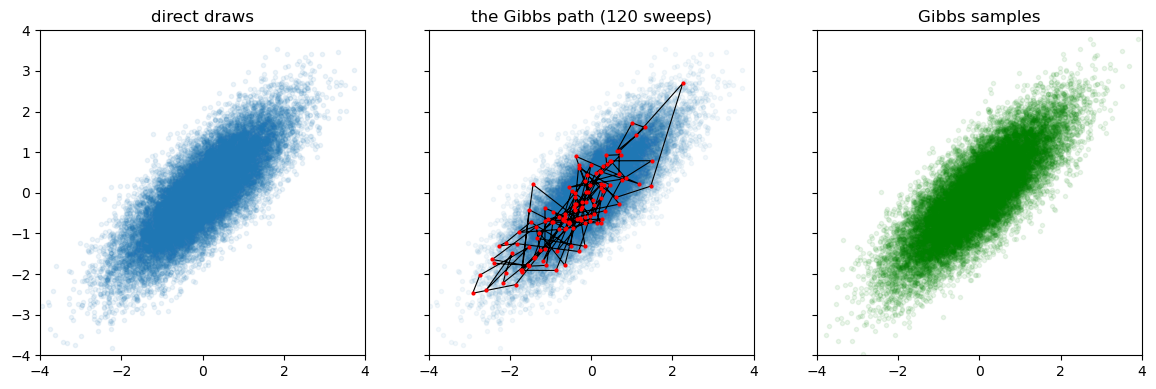

In [2]:
mean = np.array([0.0, 0.0])
cov = np.array([[1.0, 0.8], [0.8, 1.0]])

rng = np.random.default_rng(2024)
direct = (np.linalg.cholesky(cov) @ rng.normal(size=(2, 200000))).T + mean
gibbs = bm.gibbs_bivariate_gaussian(mean, cov, 200000,
                                    rng=np.random.default_rng(7))

print(f"{'quantity':>14s} {'exact':>9s} {'direct':>10s} {'Gibbs':>10s}")
print(f"{'mean x':>14s} {0.0:9.4f} {direct[:,0].mean():10.4f} {gibbs[:,0].mean():10.4f}")
print(f"{'var x':>14s} {1.0:9.4f} {direct[:,0].var():10.4f} {gibbs[:,0].var():10.4f}")
print(f"{'correlation':>14s} {0.8:9.4f} {np.corrcoef(direct.T)[0,1]:10.4f} "
      f"{np.corrcoef(gibbs.T)[0,1]:10.4f}")

short = bm.gibbs_bivariate_gaussian(mean, cov, 120, rng=np.random.default_rng(7))
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True, sharey=True)
axes[0].plot(*direct[:20000].T, ".", alpha=0.08); axes[0].set_title("direct draws")
axes[1].plot(*direct[:20000].T, ".", alpha=0.05)
axes[1].plot(*short.T, "k-", lw=0.8); axes[1].plot(*short.T, "r.", ms=4)
axes[1].set_title("the Gibbs path (120 sweeps)")
axes[2].plot(*gibbs[:20000].T, ".", alpha=0.08, color="green")
axes[2].set_title("Gibbs samples")
for ax in axes: ax.axis([-4, 4, -4, 4]); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

rho =  0.00   tau =     1.00
rho =  0.50   tau =     1.67


rho =  0.80   tau =     4.66
rho =  0.95   tau =    20.32


rho =  0.99   tau =    84.45


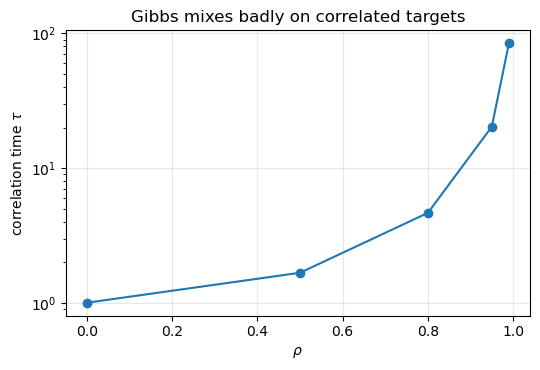

In [3]:
def tau_of(series, max_lag=400):
    d = series - series.mean()
    var = float(np.dot(d, d) / len(d))
    tau, k = 1.0, 1
    while k < max_lag:
        r = float(np.dot(d[:-k], d[k:]) / len(d) / var)
        if r < 0.0:
            break
        tau += 2.0 * r
        k += 1
    return tau

rhos = [0.0, 0.5, 0.8, 0.95, 0.99]
taus = []
for rho in rhos:
    c = np.array([[1.0, rho], [rho, 1.0]])
    s = bm.gibbs_bivariate_gaussian(mean, c, 40000, rng=np.random.default_rng(3))[:, 0]
    taus.append(tau_of(s))
    print(f"rho = {rho:5.2f}   tau = {taus[-1]:8.2f}")

plt.figure(figsize=(5.5, 3.8))
plt.semilogy(rhos, taus, "o-")
plt.xlabel(r"$\rho$"); plt.ylabel(r"correlation time $\tau$")
plt.title("Gibbs mixes badly on correlated targets")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [4]:
print(f"{'beta':>6s} {'exact e':>11s} {'Gibbs':>11s} {'Metropolis':>12s} {'accept':>9s}")
for beta in (0.25, 0.5, 1.0, 2.0):
    exact = bm.ising_chain_exact(20, beta)
    g = bm.gibbs_ising_chain(20, beta, n_sweeps=20000, rng=np.random.default_rng(1))
    m = bm.metropolis_ising_chain(20, beta, n_sweeps=20000, rng=np.random.default_rng(1))
    print(f"{beta:6.2f} {exact:11.5f} {g['energy']:11.5f} {m['energy']:12.5f} "
          f"{m['acceptance']:9.1%}")

  beta     exact e       Gibbs   Metropolis    accept


  0.25    -0.24492    -0.24565     -0.24554     75.5%


  0.50    -0.46212    -0.46266     -0.46204     53.7%


  1.00    -0.76396    -0.76679     -0.76577     23.4%


  2.00    -0.98782    -0.98998     -0.98905      1.1%


In [5]:
# Metropolis accepts Delta E = 0 with probability ONE.  On the Ising chain that
# move is a domain wall hopping one site, so under a deterministic sweep all
# walls move in lockstep, never meet, never annihilate -- and the chain is not
# ergodic.
print(f"{'beta':>6s} {'exact e':>11s} {'random order':>14s} {'in-order sweep':>16s}")
for beta in (0.5, 2.0):
    exact = bm.ising_chain_exact(20, beta)
    good = bm.metropolis_ising_chain(20, beta, n_sweeps=5000,
                                     rng=np.random.default_rng(1))
    bad = bm.metropolis_ising_chain(20, beta, n_sweeps=5000,
                                    rng=np.random.default_rng(1),
                                    random_order=False)
    print(f"{beta:6.2f} {exact:11.5f} {good['energy']:14.5f} {bad['energy']:16.5f}")
print()
print("Gibbs has no such pathology: at zero local field it draws from")
print("sigmoid(0) = 1/2 rather than flipping with certainty.  Drawing from the")
print("conditional and accepting a proposal are not always the same thing.")

  beta     exact e   random order   in-order sweep


  0.50    -0.46212       -0.46648          0.02212


  2.00    -0.98782       -0.99328          0.00004

Gibbs has no such pathology: at zero local field it draws from
sigmoid(0) = 1/2 rather than flipping with certainty.  Drawing from the
conditional and accepting a proposal are not always the same thing.


In [6]:
machine = bm.BinaryBinaryRBM(6, 4, rng=np.random.default_rng(1), scale=0.8)
checks = machine.check_identities()
for key, label in (("partition", "Z from free energy vs. brute force"),
                   ("marginal_x", "p(x) enumerated vs. closed form"),
                   ("normalisation_x", "sum_x p(x) - 1"),
                   ("normalisation_h", "sum_h p(h) - 1"),
                   ("conditional_factorisation", "p(x,h) - p(x) prod_j p(h_j|x)")):
    print(f"{label:<42s} {checks[key]:.2e}")
print()
print("The last line is the important one: the hidden units really are")
print("conditionally independent given the visible ones.  That is what the")
print("missing lateral couplings buy, and it is what makes block Gibbs work.")

Z from free energy vs. brute force         5.61e-16
p(x) enumerated vs. closed form            6.94e-17
sum_x p(x) - 1                             2.22e-16
sum_h p(h) - 1                             3.33e-16
p(x,h) - p(x) prod_j p(h_j|x)              1.04e-17

The last line is the important one: the hidden units really are
conditionally independent given the visible ones.  That is what the
missing lateral couplings buy, and it is what makes block Gibbs work.


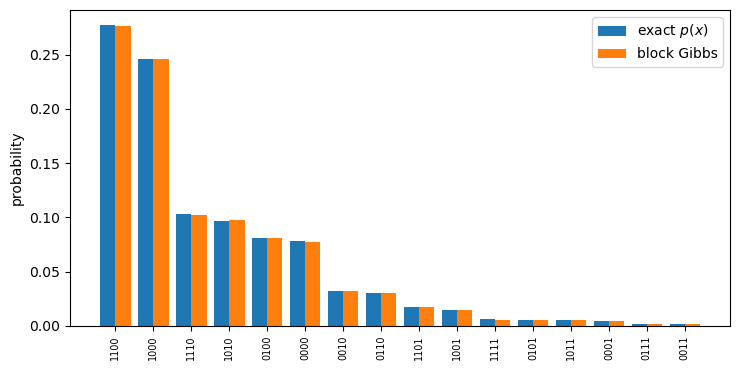

largest absolute deviation 0.00100


In [7]:
# Block Gibbs on the machine itself, against its exact marginal
small = bm.BinaryBinaryRBM(4, 3, rng=np.random.default_rng(2), scale=1.2)
exact = small.marginal_x()
draws = small.gibbs(400000, rng=np.random.default_rng(9))

states = bm.all_binary_states(4)
index = {tuple(s): i for i, s in enumerate(states)}
empirical = np.zeros(len(states))
for row in draws:
    empirical[index[tuple(row)]] += 1.0
empirical /= len(draws)

order = np.argsort(-exact)
plt.figure(figsize=(7.5, 3.8))
w = 0.4
plt.bar(np.arange(16) - w/2, exact[order], w, label="exact $p(x)$")
plt.bar(np.arange(16) + w/2, empirical[order], w, label="block Gibbs")
plt.xticks(range(16), ["".join(str(int(v)) for v in states[i]) for i in order],
           rotation=90, fontsize=7)
plt.ylabel("probability"); plt.legend(); plt.tight_layout(); plt.show()
print(f"largest absolute deviation {np.abs(exact-empirical).max():.5f}")

14 patterns out of 512


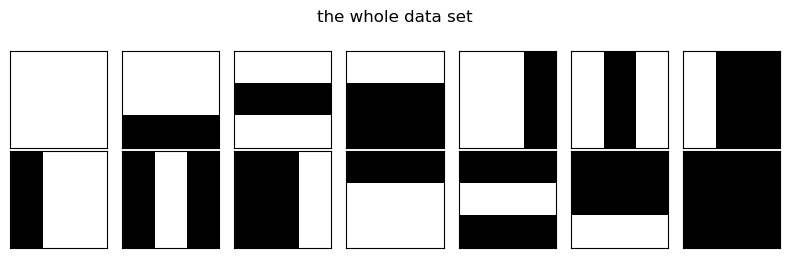

In [8]:
data = bm.bars_and_stripes(3)
print(f"{len(data)} patterns out of {2**9}")
fig, axes = plt.subplots(2, 7, figsize=(8, 2.6))
for ax, pattern in zip(axes.ravel(), data):
    ax.imshow(pattern.reshape(3, 3), cmap="binary", vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("the whole data set"); plt.tight_layout(); plt.show()

a perfect model: log-likelihood -2.6391, KL 0

   epoch   log-likelihood     KL(f||p)
       0          -6.2386       3.5995
    4000          -3.1271       0.4880
    8000          -2.8440       0.2050
   12000          -2.8718       0.2328
   16000          -2.7309       0.0918
   20000          -2.7775       0.1385


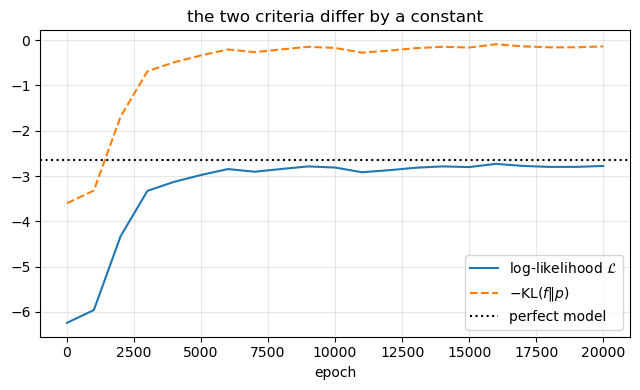


the constant is the entropy of the data, -log(1/14) = 2.6391
model probability on the 14 valid patterns: 97.9%  (random: 2.7%)


In [9]:
machine, data, history = bm.train_bars_and_stripes(
    n_hidden=8, epochs=20000, learning_rate=0.1, k=5, report_every=1000)

target = math.log(1.0 / len(data))
print(f"a perfect model: log-likelihood {target:.4f}, KL 0\n")
print(f"{'epoch':>8s} {'log-likelihood':>16s} {'KL(f||p)':>12s}")
for epoch, ll, kl in history[::4]:
    print(f"{epoch:8d} {ll:16.4f} {kl:12.4f}")

epochs = [h[0] for h in history]
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(epochs, [h[1] for h in history], label=r"log-likelihood $\mathcal{L}$")
ax.plot(epochs, [-h[2] for h in history], "--", label=r"$-\mathrm{KL}(f\|p)$")
ax.axhline(target, color="k", ls=":", label="perfect model")
ax.set_xlabel("epoch"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("the two criteria differ by a constant")
plt.tight_layout(); plt.show()
print(f"\nthe constant is the entropy of the data, -log(1/14) = {-target:.4f}")
print(f"model probability on the 14 valid patterns: "
      f"{float(np.sum(machine.marginal_x_formula(data))):.1%}  "
      f"(random: {14/512:.1%})")

In [10]:
# The number of Gibbs steps in CD-k matters
print(f"{'k':>4s} {'log-likelihood':>16s} {'KL(f||p)':>12s}")
for k in (1, 2, 5, 10):
    _, _, h = bm.train_bars_and_stripes(n_hidden=8, epochs=20000,
                                        learning_rate=0.1, k=k,
                                        report_every=20000)
    print(f"{k:4d} {h[-1][1]:16.4f} {h[-1][2]:12.4f}")
print()
print("CD-1 is the cheapest and the most biased: one Gibbs step from the data")
print("is nowhere near the model's equilibrium.  It still works, which is the")
print("surprising and much-discussed fact about the algorithm.")

   k   log-likelihood     KL(f||p)


   1          -3.3710       0.7319


   2          -3.0410       0.4019


   5          -2.7775       0.1385


  10          -2.7327       0.0937

CD-1 is the cheapest and the most biased: one Gibbs step from the data
is nowhere near the model's equilibrium.  It still works, which is the
surprising and much-discussed fact about the algorithm.


p(x): summed over h vs. closed form      4.63e-16
p(h): integrated over x vs. closed form  3.78e-14
p(x|h) vs. N(a + Wh, sigma^2)            8.35e-16


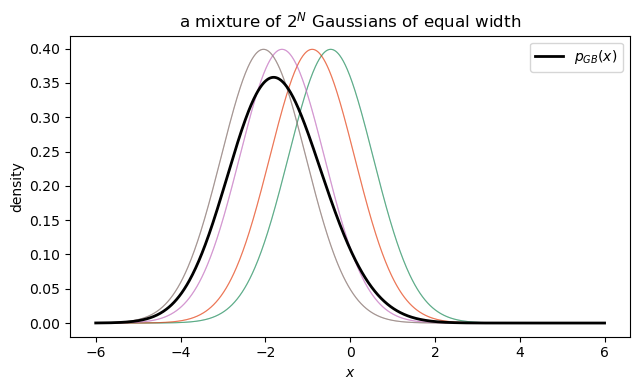

In [11]:
_trapz = getattr(np, "trapezoid", None) or np.trapz
gb = bm.GaussianBinaryRBM(1, 3, sigma=1.0, rng=np.random.default_rng(4), scale=0.7)
checks = gb.check_identities()
print(f"p(x): summed over h vs. closed form      {checks['marginal_x']:.2e}")
print(f"p(h): integrated over x vs. closed form  {checks['marginal_h']:.2e}")
print(f"p(x|h) vs. N(a + Wh, sigma^2)            {checks['conditional_density']:.2e}")

# the mixture of Gaussians, drawn
grid = np.linspace(-6, 6, 800).reshape(-1, 1)
plt.figure(figsize=(6.5, 4))
for h in bm.all_binary_states(3):
    mu = float(gb.mean_x_given_h(h)[0, 0])
    comp = np.exp(-(grid[:, 0] - mu)**2 / 2) / math.sqrt(2 * math.pi)
    plt.plot(grid[:, 0], comp, lw=0.8, alpha=0.5)
total = gb.unnormalised_marginal_x(grid)
plt.plot(grid[:, 0], total / _trapz(total, grid[:, 0]), "k", lw=2,
         label=r"$p_{GB}(x)$")
plt.xlabel("$x$"); plt.ylabel("density"); plt.legend()
plt.title("a mixture of $2^N$ Gaussians of equal width")
plt.tight_layout(); plt.show()

In [12]:
d = bm.check_nqs_derivatives()
for key, label in (("grad_x", "d ln Psi / d x_m"),
                   ("laplacian_x", "d^2 ln Psi / d x_m^2"),
                   ("grad_a", "d ln Psi / d a_m"),
                   ("grad_b", "d ln Psi / d b_n"),
                   ("grad_W", "d ln Psi / d w_mn"),
                   ("local_energy", "E_L vs. numerical H Psi / Psi")):
    print(f"{label:<32s} {d[key]:.2e}")

d ln Psi / d x_m                 1.21e-11
d^2 ln Psi / d x_m^2             4.51e-09
d ln Psi / d a_m                 9.84e-12
d ln Psi / d b_n                 2.47e-12
d ln Psi / d w_mn                1.58e-11
E_L vs. numerical H Psi / Psi    3.17e-07


In [13]:
print("Non-interacting, exact 2.000000:")
for n_hidden in (2, 4):
    nqs = bm.NeuralQuantumState(2, 2, n_hidden, interaction=False,
                                rng=np.random.default_rng(17), scale=0.05)
    nqs.optimise(learning_rate=0.05, max_iter=60, n_cycles=400, n_walkers=200)
    final = nqs.sample(n_cycles=3000, n_walkers=500,
                       rng=np.random.default_rng(99), keep_samples=True)
    err = blocking(final["samples"])[1]
    print(f"   N = {n_hidden}:  E = {final['energy']:.6f} +/- {err:.6f}   "
          f"variance {final['variance']:.2e}")
print()
print("The variance collapses: the optimiser has found the exact eigenstate,")
print("where E_L is constant.  This is the zero-variance principle of ch. 14.")

Non-interacting, exact 2.000000:


   N = 2:  E = 2.000080 +/- 0.000014   variance 1.21e-04


   N = 4:  E = 2.000049 +/- 0.000013   variance 1.11e-04

The variance collapses: the optimiser has found the exact eigenstate,
where E_L is constant.  This is the zero-variance principle of ch. 14.


Interacting, exact 3.000000:
   N           E      error   variance   E - exact


   2     3.14840    0.00185     3.3093    +0.14840


   4     3.08227    0.00173     3.1227    +0.08227


   8     3.09596    0.00171     2.9246    +0.09596


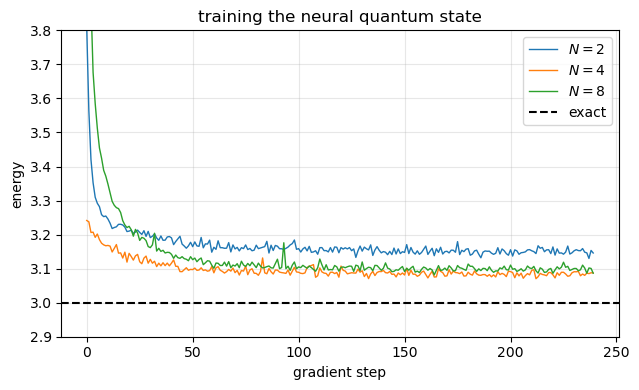

In [14]:
print("Interacting, exact 3.000000:")
print(f"{'N':>4s} {'E':>11s} {'error':>10s} {'variance':>10s} {'E - exact':>11s}")
results = []
for n_hidden in (2, 4, 8):
    nqs = bm.NeuralQuantumState(2, 2, n_hidden, interaction=True,
                                rng=np.random.default_rng(17), scale=0.4)
    history = nqs.optimise_annealed()
    final = nqs.sample(n_cycles=3000, n_walkers=500,
                       rng=np.random.default_rng(99), keep_samples=True)
    err = blocking(final["samples"])[1]
    results.append((n_hidden, history, final, err))
    print(f"{n_hidden:4d} {final['energy']:11.5f} {err:10.5f} "
          f"{final['variance']:10.4f} {final['energy']-3.0:+11.5f}")

fig, ax = plt.subplots(figsize=(6.5, 4))
for n_hidden, history, _, _ in results:
    ax.plot([h[1] for h in history], lw=1, label=f"$N={n_hidden}$")
ax.axhline(3.0, color="k", ls="--", label="exact")
ax.set_xlabel("gradient step"); ax.set_ylabel("energy")
ax.set_ylim(2.9, 3.8); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("training the neural quantum state")
plt.tight_layout(); plt.show()

                            method       energy        error
         Hartree-Fock, 42 orbitals     3.161921     0.161921
        RBM, N=4, no physics input     3.082268     0.082268
                  MP2, 42 orbitals     3.027038     0.027038
                 CCSD, 42 orbitals     3.013626     0.013626
        VMC, Pade-Jastrow (ch. 14)     3.000549     0.000549
                      exact (Taut)     3.000000     0.000000


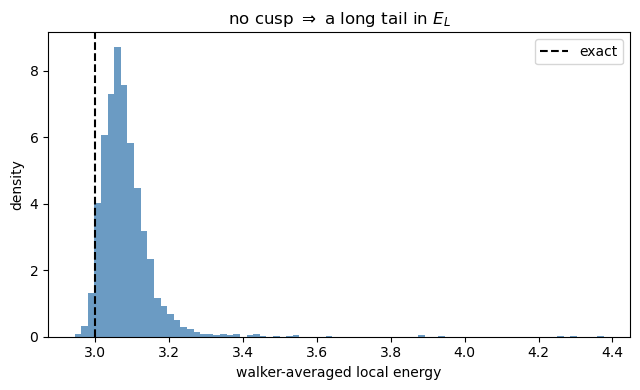

In [15]:
print(f"{'method':>34s} {'energy':>12s} {'error':>12s}")
for label, value in (("Hartree-Fock, 42 orbitals", 3.161921),
                     ("RBM, N=4, no physics input", results[1][2]["energy"]),
                     ("MP2, 42 orbitals", 3.027038),
                     ("CCSD, 42 orbitals", 3.013626),
                     ("VMC, Pade-Jastrow (ch. 14)", 3.000549),
                     ("exact (Taut)", 3.000000)):
    print(f"{label:>34s} {value:12.6f} {value-3.0:12.6f}")

# why the variance is so large: the local energy has a 1/r_12 tail
series = results[1][2]["samples"]
plt.figure(figsize=(6.5, 4))
plt.hist(series, bins=80, density=True, color="steelblue", alpha=0.8)
plt.axvline(3.0, color="k", ls="--", label="exact")
plt.xlabel("walker-averaged local energy"); plt.ylabel("density")
plt.title("no cusp $\\Rightarrow$ a long tail in $E_L$")
plt.legend(); plt.tight_layout(); plt.show()